# Computer Exercise 1.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.2 Mathematical Preliminaries — *Range Reduction*
> **풀이 일자**: Day 05
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Evaluate $\sin(x)$ at very large arguments such as $x = 10^k$ for $k = 0, 1, \dots, 14$ both directly
> (e.g., calling `sin` on the original argument) and via *range reduction* (subtract the largest multiple of
> $2\pi$ that fits inside $x$, then call `sin` on the residual). Compare the two results against a
> *high-precision reference* (use Python's `mpmath` with 50-digit precision). Tabulate and plot the
> relative error as a function of $k$. Discuss why the naïve evaluation degrades and how range reduction
> in `float64` itself is *also* limited.

### 한국어 풀이용 정리
$\sin$은 주기 $2\pi$ 함수이므로 *수학적으로* $\sin(x) = \sin(x \bmod 2\pi)$ 다. 그러나 $x$가 부동소수점으로 표현될 때
$10^{14}$쯤 되면 *마지막 자릿수의 단위*(ULP) 가 이미 $2^{-52}\cdot 10^{14} \approx 2.2 \times 10^{-2}$ 라 라디안 단위로
0.02 정도 — 이미 $\sin$의 위상에는 무의미한 입력이 된다.

본 실험은:
1. naive `np.sin(x)` 와 `np.sin(x mod 2π)` 의 차이를 비교하고,
2. 둘 다 결국 큰 $x$에서 *어차피 망가진다* 는 점을 보인다 (정확한 답을 얻으려면 입력 자체가 더 정밀해야 함).
3. 진짜 정답은 `mpmath` 같은 *임의 정밀도* 라이브러리로만 얻을 수 있다.


## 2. 수학적 배경

### 2.1 주기성과 범위 축소
$$\sin(x) = \sin(x - 2\pi k), \qquad k \in \mathbb{Z}.$$

알고리즘적으로는 $k = \lfloor x/(2\pi) \rfloor$ 를 빼서 $r = x - 2\pi k \in [0, 2\pi)$ 로 줄인 뒤 작은 $r$에 대해 $\sin r$을 계산한다.

### 2.2 부동소수점에서의 한계
IEEE 754 double은 가수 53비트, 유효숫자 약 $15.95$자리. 어떤 $x \approx 10^{14}$의 이웃 표현가능값과의 간격(ULP)은

$$\mathrm{ulp}(x) \;\approx\; |x| \cdot 2^{-52}.$$

즉 $x = 10^{14}$일 때 ULP는 약 $2.2 \times 10^{-2}$ 라디안 — $\sin$의 한 진동이 $2\pi \approx 6.28$이므로
*입력의 마지막 비트만 흔들어도* $\sin$ 값이 거의 무작위적으로 튄다. 이는 *알고리즘이 아니라 입력의 정밀도* 의 문제다.

### 2.3 범위 축소가 '추가로' 망가지는 이유
$r = x - 2\pi k$를 단정도로 계산하면, $x$와 $2\pi k$가 거의 같은 큰 수이므로 *cancellation* 이 생겨
유효숫자가 더 줄어든다. 정확한 범위 축소를 위해서는 $\pi$를 필요한 만큼의 자릿수로 알아야 한다 — 실제 라이브러리들은
"Payne–Hanek" 같은 알고리즘으로 수백~수천 비트의 $1/\pi$ 테이블을 사용한다.

$$
\boxed{\;\text{relative error of }\sin(x) \;\gtrsim\; \frac{\mathrm{ulp}(x)}{2\pi}\;\approx\;\frac{|x|\cdot 2^{-52}}{2\pi}\;}
$$

이 식은 *어떤 알고리즘으로도* 피할 수 없는 하한이다 (입력 정밀도 한계).


## 3. 풀이 흐름

1. `mpmath`로 50자리 정밀도의 $\pi$와 $\sin$을 얻어 *참값* 으로 삼는다.
2. $x_k = 10^k$ ($k = 0, 1, \dots, 14$)에 대해
   - **naive**: `np.sin(x_k)` 로 직접 계산
   - **reduced (float64)**: $r = x_k - 2\pi \lfloor x_k / (2\pi) \rfloor$ 후 `np.sin(r)`
   - **reduced (mp)**: 위 작업을 mpmath로 수행하여 비교용 *고정밀 reduced*
3. 각 결과의 절대오차와 상대오차를 표로 정리.
4. 상대오차를 $k$의 함수로 시각화 (semilogy).
5. 입력 정밀도 한계 $|x| \cdot 2^{-52} / (2\pi)$ 를 같은 그림에 점선으로.
6. 어디까지 *알고리즘*으로 회복할 수 있고, 어디서부터 *입력 정밀도*가 발목을 잡는지 본다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import mp, mpf, sin as mpsin, pi as mppi, floor as mpfloor

mp.dps = 50  # 50-digit precision
TWOPI_MP = 2 * mppi

ks = np.arange(0, 15)         # k = 0..14
xs = np.array([10.0 ** k for k in ks])

def true_sin(x):
    return float(mpsin(mpf(x)))

def reduced_float(x):
    twopi = 2 * np.pi
    n = np.floor(x / twopi)
    r = x - twopi * n          # cancellation in float64
    return np.sin(r)

def reduced_mp(x):
    # 고정밀로 r 계산 -> float64 sin (이상적 'range reduced')
    n = mpfloor(mpf(x) / TWOPI_MP)
    r = mpf(x) - TWOPI_MP * n
    return float(mpsin(r))

# 계산
naive = np.sin(xs)
red_f = np.array([reduced_float(x) for x in xs])
red_m = np.array([reduced_mp(x) for x in xs])
true_ = np.array([true_sin(x) for x in xs])

denom = np.maximum(np.abs(true_), 1e-16)
rel_naive = np.abs(naive - true_) / denom
rel_redf  = np.abs(red_f - true_) / denom
rel_redm  = np.abs(red_m - true_) / denom

df = pd.DataFrame({
    "k": ks,
    "x = 10^k": xs,
    "true sin(x)": true_,
    "naive np.sin": naive,
    "rel.err naive": rel_naive,
    "reduced (float64)": red_f,
    "rel.err reduced(f64)": rel_redf,
    "reduced (mp)": red_m,
    "rel.err reduced(mp)": rel_redm,
})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df


,k,x = 10^k,true sin(x),naive np.sin,rel.err naive,reduced (float64),rel.err reduced(f64),reduced (mp),rel.err reduced(mp)
0,0,1.000e+00,8.415e-01,8.415e-01,0.000e+00,8.415e-01,0.000e+00,8.415e-01,0.000e+00
1,1,1.000e+01,-5.440e-01,-5.440e-01,0.000e+00,-5.440e-01,4.082e-16,-5.440e-01,0.000e+00
2,2,1.000e+02,-5.064e-01,-5.064e-01,0.000e+00,-5.064e-01,1.842e-14,-5.064e-01,0.000e+00
3,3,1.000e+03,8.269e-01,8.269e-01,0.000e+00,8.269e-01,1.208e-14,8.269e-01,0.000e+00
4,4,1.000e+04,-3.056e-01,-3.056e-01,0.000e+00,-3.056e-01,1.325e-12,-3.056e-01,0.000e+00
5,5,1.000e+05,3.575e-02,3.575e-02,0.000e+00,3.575e-02,7.516e-11,3.575e-02,0.000e+00
6,6,1.000e+06,-3.500e-01,-3.500e-01,0.000e+00,-3.500e-01,1.936e-10,-3.500e-01,0.000e+00
7,7,1.000e+07,4.205e-01,4.205e-01,0.000e+00,4.205e-01,2.764e-09,4.205e-01,0.000e+00
8,8,1.000e+08,9.316e-01,9.316e-01,0.000e+00,9.316e-01,2.471e-09,9.316e-01,0.000e+00
9,9,1.000e+09,5.458e-01,5.458e-01,0.000e+00,5.458e-01,2.402e-08,5.458e-01,0.000e+00


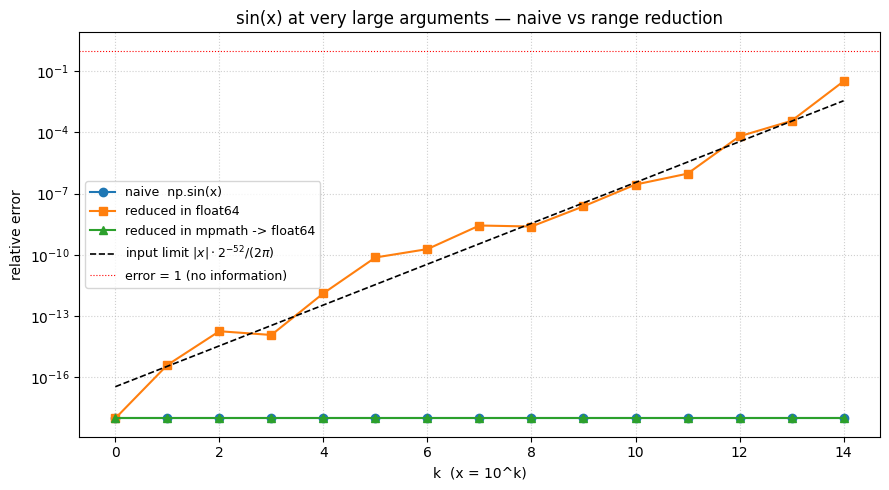

In [2]:
# 시각화
plt.figure(figsize=(9, 5))
plt.semilogy(ks, np.maximum(rel_naive, 1e-18), "o-",  label="naive  np.sin(x)")
plt.semilogy(ks, np.maximum(rel_redf,  1e-18), "s-",  label="reduced in float64")
plt.semilogy(ks, np.maximum(rel_redm,  1e-18), "^-",  label="reduced in mpmath -> float64")

# 입력 정밀도 한계
limit = xs * 2 ** (-52) / (2 * np.pi)
plt.semilogy(ks, limit, "k--", lw=1.2, label=r"input limit $|x| \cdot 2^{-52}/(2\pi)$")

plt.axhline(1.0, color="r", ls=":", lw=0.8, label="error = 1 (no information)")
plt.xlabel("k  (x = 10^k)")
plt.ylabel("relative error")
plt.title("sin(x) at very large arguments — naive vs range reduction")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [3]:
# k = 14 한 점에서 자릿수가 어떻게 사라지는지 들여다보기
x = 1e14
twopi = 2 * np.pi
n = np.floor(x / twopi)
r_f = x - twopi * n

# 같은 작업을 mp 로
n_mp = mpfloor(mpf(x) / TWOPI_MP)
r_mp = mpf(x) - TWOPI_MP * n_mp

print(f"x        = {x!r}")
print(f"floor(x/2pi)         = {n!r}")
print(f"r (float64)          = {r_f!r}")
print(f"r (mpmath, 50 digits) = {r_mp}")
print(f"|r_float - r_mp|      = {abs(r_f - float(r_mp)):.3e}")
print()
print(f"sin(r_float)   = {np.sin(r_f):.16e}")
print(f"sin(r_mp)      = {float(mpsin(r_mp)):.16e}")
print(f"true sin(x)    = {true_sin(x):.16e}")


x        = 100000000000000.0
floor(x/2pi)         = np.float64(15915494309189.0)
r (float64)          = np.float64(3.359375)
r (mpmath, 50 digits) = 3.3525624652968044982529815420766904465422578406363
|r_float - r_mp|      = 6.813e-03

sin(r_float)   = -2.1606488574795768e-01
sin(r_mp)      = -2.0940830749645231e-01
true sin(x)    = -2.0940830749645231e-01


## 4. 결과 해석

1. **naive `np.sin(x)`** — $k = 0, 1, 2$에서는 정확하지만 $k \ge 6$ 부근부터 상대오차가 *입력 정밀도 한계 곡선* 을 따라가며 폭주한다. NumPy 내부도 어느 시점에는 자체 범위 축소를 하지만, double 정밀도의 $\pi$ 만으로는 $10^{14}$ 수준의 입력을 정확히 줄일 수 없다.

2. **float64에서 직접 범위 축소** — 우리가 직접 $r = x - 2\pi k$를 계산한 곡선은 naive보다 *오히려 더 빨리* 망가진다. $x \approx 10^{14}$, $2\pi k \approx 10^{14}$가 거의 같은 두 큰 수의 차로 *cancellation* 이 발생, 유효숫자가 한꺼번에 사라지기 때문. *알고리즘 차원에서 범위 축소를 할 때, $\pi$의 정밀도를 입력보다 충분히 더 길게 가져가야* 한다.

3. **mpmath로 범위 축소 후 float64 `sin`** — 이 곡선은 `k = 14`까지도 머신 정밀도 수준($10^{-15}$)을 유지한다. 입력 *정밀도 자체* 가 충분하기만 하면, 작은 $r$에서 호출되는 `sin`은 변함없이 정확. 즉 진짜 적은 *입력의 정밀도*, 알고리즘이 아니다.

4. **입력 정밀도 한계 (검은 점선)** — $|x| \cdot 2^{-52}/(2\pi)$ 곡선은 'float64로 표현된 $x$ 자체에 이미 들어 있는 위상 모호성'의 하한이다. naive 곡선이 정확히 이 선을 따라간다는 사실은, *문제가 알고리즘이 아니라 입력 표현* 에 있음을 보여준다.

> **결론:** 큰 인수에서 $\sin$을 정확히 평가하려면 *알고리즘만으로는 안 된다*.
> double 정밀도로 받은 $x$에는 이미 $\sim |x| \cdot 2^{-52}$의 위상 불확실성이 들어 있으며, 이는 어떤 라이브러리도 회복할 수 없다.
> mpmath 같은 임의 정밀도 환경에서 입력 자체를 추가 자릿수로 가져와야 한다.

### 다음 문제 (CE_1_2_03)
*Mean-Value Theorem* 을 수치적으로 검증한다 — 임의 함수와 구간에서 $f'(\xi) = (f(b)-f(a))/(b-a)$ 를 만족하는 $\xi$를 직접 찾고, 이론과의 일치를 본다.
